<a href="https://colab.research.google.com/github/ChenHY1217/Projects-In-MLAI/blob/main/ProjectsinMLAIhw5_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNNs, AEs, GANs, Attention Mechanism

## Task 1 - CNNs

### Part 1 - Baseline Convolution

Loading GTSRB dataset

This dataset is downloaded directly using torchvision.datasets so no link is needed.

100%|██████████| 187M/187M [00:00<00:00, 206MB/s]
100%|██████████| 89.0M/89.0M [00:00<00:00, 237MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 2.74MB/s]


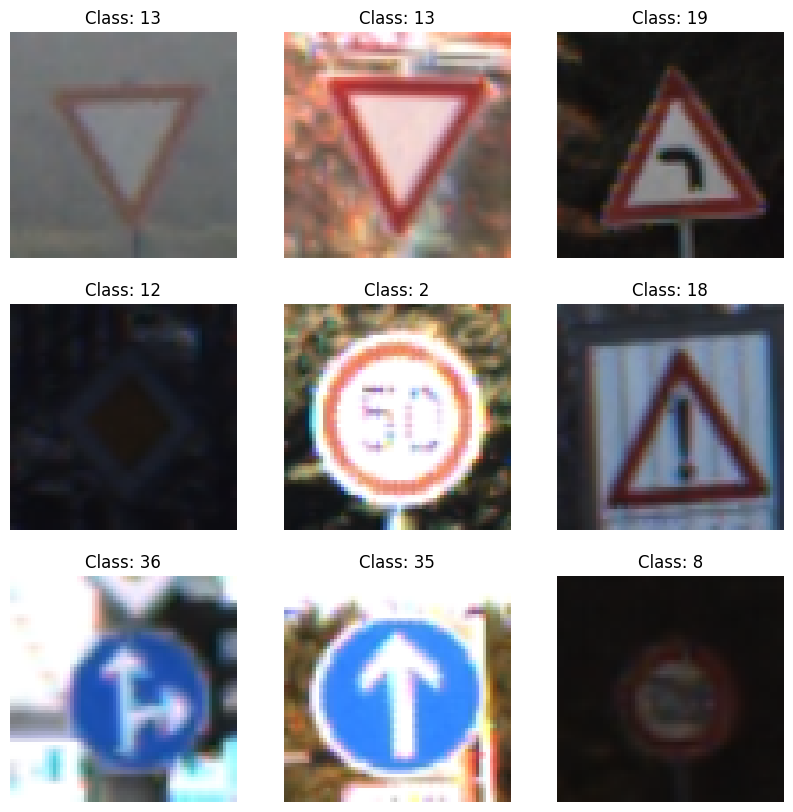

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np

IMG_SIZE = 64
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor() # Converts to [0, 1] range and moves channels to the front (C, H, W)
])

# download data
train_dataset = datasets.GTSRB(root='./data', split='train', transform=transform, download=True)
test_dataset = datasets.GTSRB(root='./data', split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# visualization function
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")

# visualize some images
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    imshow(images[i])
    plt.title(f"Class: {labels[i].item()}")
plt.show()

Create CNN

In [ ]:
class TrafficSignCNN(nn.Module):
  def __init__(self, num_classes=43):
    super(TrafficSignCNN, self).__init__()

    self.convs = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
    )

    self.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear( 128 * 8 * 8, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, num_classes)
    )

  def forward(self, x):
    x = self.convs(x)
    x = self.fc(x)
    return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TrafficSignCNN().to(device)
print(model)

TrafficSignCNN(
  (convs): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=43, bias=True)
  )
)


I chose to design the CNN with 3 convolutional layers each followed by a ReLU activation and a Max pooling of 2x2. Then it has a fully connected layer with flattening of the images and two linear layers with ReLU and dropout. This allows us to double the feature channels and capture the complex shapes within the images. Meanwhile, we reduce the spatial dimensions with max pooling. Combined with the linear layers, this allows us to learn the complex shapes in the images, maintain reasonable sizings, and produce predictions.

Training and Testing

In [ ]:
# loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for inputs, labels in train_loader:
      inputs, labels = inputs.to(device), labels.to(device)

      optimizer.zero_grad()

      # Forward pass
      outputs = model(inputs)
      loss = criterion(outputs, labels)

      # Backward pass
      loss.backward()
      optimizer.step()

      running_loss += loss.item()

      # Calculate training accuracy
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f} - Accuracy: {100 * correct / total:.2f}%")

# Evaluate the model
model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
  for inputs, labels in test_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      loss = criterion(outputs, labels)

      test_loss += loss.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(f"\nFinal Test Evaluation:")
print(f"Test Loss: {test_loss/len(test_loader):.4f}")
print(f"Test Accuracy: {100 * correct / total:.2f}%")

Epoch 1/10 - Loss: 2.2656 - Accuracy: 33.81%
Epoch 2/10 - Loss: 0.8592 - Accuracy: 70.88%
Epoch 3/10 - Loss: 0.4752 - Accuracy: 83.72%
Epoch 4/10 - Loss: 0.3406 - Accuracy: 88.48%
Epoch 5/10 - Loss: 0.2681 - Accuracy: 90.78%
Epoch 6/10 - Loss: 0.2335 - Accuracy: 92.00%
Epoch 7/10 - Loss: 0.1938 - Accuracy: 93.48%
Epoch 8/10 - Loss: 0.1760 - Accuracy: 94.08%
Epoch 9/10 - Loss: 0.1504 - Accuracy: 94.79%
Epoch 10/10 - Loss: 0.1413 - Accuracy: 95.06%

Final Test Evaluation:
Test Loss: 0.3029
Test Accuracy: 94.23%


We use accuracy as a metric to determine the percentage of traffic signs being correctly identified. It is an excellent primary metric here because the GTSRB dataset classes are reasonably well-represented, making accuracy a reliable indicator of real-world performance.

We also measure the cross-entropy loss. This allows us to heavily penalize predictions that are confident but wrong.

### Part 2 - Transfer Learning

We will use the ResNet50 model.

In [ ]:
transform_res = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_res = datasets.GTSRB(root='./data', split='train', transform=transform_res, download=True)
test_dataset_res = datasets.GTSRB(root='./data', split='test', transform=transform_res, download=True)

train_loader_res = DataLoader(train_dataset_res, batch_size=BATCH_SIZE, shuffle=True)
test_loader_res = DataLoader(test_dataset_res, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

model_res = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model_res.parameters():
    param.requires_grad = False

num_ftrs = model_res.fc.in_features
model_res.fc = nn.Linear(num_ftrs, 43)
model_res = model_res.to(device)

cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer_res = optim.Adam(model_res.fc.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
  model_res.eval()
  model_res.fc.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for inputs, labels in train_loader_res:
      inputs, labels = inputs.to(device), labels.to(device)

      optimizer_res.zero_grad()

      outputs = model_res(inputs)
      loss = criterion(outputs, labels)

      loss.backward()
      optimizer_res.step()

      running_loss += loss.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader_res):.4f} - Accuracy: {100 * correct / total:.2f}%")

model_res.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
  for inputs, labels in test_loader_res:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model_res(inputs)
      loss = criterion(outputs, labels)

      test_loss += loss.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(f"\nResNet50 Final Test Evaluation:")
print(f"Test Loss: {test_loss/len(test_loader_res):.4f}")
print(f"Test Accuracy: {100 * correct / total:.2f}%")


Epoch 1/10 - Loss: 1.1100 - Accuracy: 69.09%
Epoch 2/10 - Loss: 0.4954 - Accuracy: 86.30%
Epoch 3/10 - Loss: 0.3483 - Accuracy: 90.62%
Epoch 4/10 - Loss: 0.2732 - Accuracy: 92.72%
Epoch 5/10 - Loss: 0.2268 - Accuracy: 94.00%
Epoch 6/10 - Loss: 0.1907 - Accuracy: 95.26%
Epoch 7/10 - Loss: 0.1680 - Accuracy: 95.64%
Epoch 8/10 - Loss: 0.1478 - Accuracy: 96.15%
Epoch 9/10 - Loss: 0.1285 - Accuracy: 96.87%
Epoch 10/10 - Loss: 0.1169 - Accuracy: 97.11%

ResNet50 Final Test Evaluation:
Test Loss: 1.0666
Test Accuracy: 71.90%


There are some significant differences between the ResNet50 and our implementation. The ResNet50 model reached high accuracy after the first epoch, significantly beating our model.

However, we see that during the final test evaluation, it yielded worst results. This is likely due to overfitting as the ResNet50's weights were trained on ImageNet which is massive compared to the traffic sign dataset. This caused it to memorize the training set but fail to generalize on test data.

Other potential issues can be that to match our dataset with what ResNet50 expects, we needed to stretch our images. This makes it harder to classify blurry traffic signs.

### Part 3 - Data Augmentation

In [ ]:
transform_train_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15), # Rotates the image randomly between -15 and +15 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Shifts the image slightly
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjusts lighting randomly
    transforms.ToTensor()
])

transform_test_std = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# load with augmentations
train_dataset_aug = datasets.GTSRB(root='./data', split='train', transform=transform_train_aug, download=True)
test_dataset_std = datasets.GTSRB(root='./data', split='test', transform=transform_test_std, download=True)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
test_loader_std = DataLoader(test_dataset_std, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
model_aug = TrafficSignCNN().to(device)

criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.001)

epochs = 15

for epoch in range(epochs):
  model_aug.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for inputs, labels in train_loader_aug:
      inputs, labels = inputs.to(device), labels.to(device)

      optimizer_aug.zero_grad()
      outputs = model_aug(inputs)
      loss = criterion_aug(outputs, labels)

      loss.backward()
      optimizer_aug.step()

      running_loss += loss.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader_aug):.4f} - Accuracy: {100 * correct / total:.2f}%")

model_aug.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
  for inputs, labels in test_loader_std:

      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model_aug(inputs)
      loss = criterion_aug(outputs, labels) # Changed from 'criterion' to 'criterion_aug'

      test_loss += loss.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(f"\nAugmented Model Final Test Evaluation:")
print(f"Test Loss: {test_loss/len(test_loader_std):.4f}")
print(f"Test Accuracy: {100 * correct / total:.2f}%")

Epoch 1/15 - Loss: 2.6563 - Accuracy: 23.30%
Epoch 2/15 - Loss: 1.7526 - Accuracy: 41.78%
Epoch 3/15 - Loss: 1.3939 - Accuracy: 52.20%
Epoch 4/15 - Loss: 1.1294 - Accuracy: 60.83%
Epoch 5/15 - Loss: 0.9098 - Accuracy: 68.38%
Epoch 6/15 - Loss: 0.7638 - Accuracy: 73.44%
Epoch 7/15 - Loss: 0.6502 - Accuracy: 77.56%
Epoch 8/15 - Loss: 0.5519 - Accuracy: 81.23%
Epoch 9/15 - Loss: 0.4799 - Accuracy: 83.57%
Epoch 10/15 - Loss: 0.4181 - Accuracy: 86.16%
Epoch 11/15 - Loss: 0.3786 - Accuracy: 87.35%
Epoch 12/15 - Loss: 0.3351 - Accuracy: 88.79%
Epoch 13/15 - Loss: 0.3046 - Accuracy: 90.04%
Epoch 14/15 - Loss: 0.2735 - Accuracy: 90.94%
Epoch 15/15 - Loss: 0.2463 - Accuracy: 91.91%

Augmented Model Final Test Evaluation:
Test Loss: 0.3417
Test Accuracy: 94.28%


I noticed that my training accuracies are lower than what it was for Part 1, but my test accuracy was much higher. This is because the data augmentation serves as a strong regularizer. By increasing the diversity of the dataset through rotations and translations, we reduce overfitting. This allows the model to learn the core features of the signs and generalize better on the test dataset.

###